In [1]:
from qeep import plot

import matplotlib.pyplot as plt

import numpy as np

import matplotlib.pyplot as plt

import yaml
import jax.numpy as jnp

import os
os.environ['PATH'] = os.path.expanduser("~/texlive/2025/bin/aarch64-linux") + ":" + os.environ['PATH']

style_path = "paper.mplstyle"
plt.style.use(style_path)

/users/odarwish/qeep/qeep/plot.py:75: SyntaxWarning: invalid escape sequence '\m'
  """"


In [2]:
configuration = '../../configs/abacus/config_desi_asymm.yaml'
configuration_full_weights = '../../configs/abacus/config_desi_asymm_full_var.yaml'

with open(configuration, 'r') as f:
    config = yaml.safe_load(f)

ps_main_directory = "../"+config['power_spectrum']['main_directory']
name_config = config['name']
gen_nl_power = np.loadtxt(ps_main_directory+name_config+"/"+config['power_spectrum']['nonlinear'])
gen_power = np.loadtxt(ps_main_directory+name_config+"/"+config['power_spectrum']['linear'])

kr_config = config['k_range']
kmin = kr_config['kmin']
kmax = kr_config['kmax']
k_samples = kr_config['k_samples']
k_min_analysis = kr_config['k_min_analysis']
k_max_analysis = kr_config['k_max_analysis']

kmin_max = 2*k_min_analysis
Ks_ = np.linspace(k_min_analysis, kmin_max, 20)
Ks = np.logspace(np.log10(kmin_max), np.log10(k_max_analysis), k_samples)
Ks = np.concatenate([Ks_, Ks])
Ks = np.unique(Ks)

pnlinf = lambda kmag: jnp.interp(kmag, gen_nl_power[:,0], gen_nl_power[:,1])
plinf = lambda kmag: jnp.interp(kmag, gen_power[:,0], gen_power[:,1])

In [3]:
name = config["name"]

path = f"../../results/{name}/"

norm = np.load(path+f"analysis_theory_normalization_AB.npy", allow_pickle = True).item()
var = np.load(path+f"analysis_theory_variance_AB.npy", allow_pickle = True).item()
bis = np.load(path+f"analysis_theory_shot_bispectrum_AB.npy", allow_pickle = True).item()
tris = np.load(path+f"analysis_theory_shot_trispectrum_AB.npy", allow_pickle = True).item()

### Responses

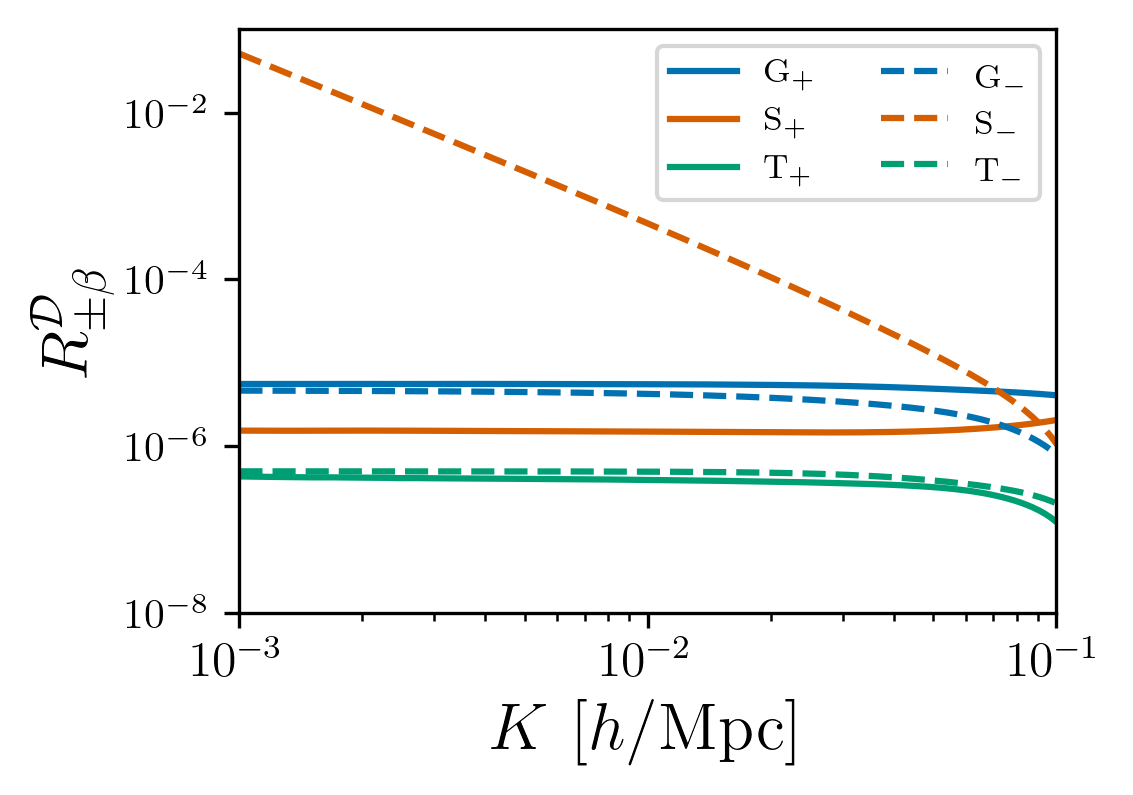

In [4]:
mainkey = "n"
kother = "sa" 

# ---- FIGURE CREATION ----
# Create figure with golden ratio and higher dpi
#fig = plt.figure(figsize = (my_width, my_width/golden))

fig = plt.figure(figsize=(plot.size[0], plot.size[1]*1.2), dpi=plot.DPI, facecolor='white')
# Use GridSpec for more control over plot layout
gs = plot.GridSpec(1, 1, figure=fig, left=0.15, right=0.95, bottom=0.15, top=0.92)
ax = fig.add_subplot(gs[0, 0])

i = 0
color = plot.COLORBLIND_PALETTE[i % len(plot.COLORBLIND_PALETTE)]


# Set up clean, professional plot styling with pure white background
ax.set_facecolor('white')
for spine in ax.spines.values():
    spine.set_linewidth(0.8)
    spine.set_color('black')

keys = ["g", "s", "t", "ga", "sa", "ta"]

normalized = False

if normalized:
    N = norm[(mainkey, mainkey)]**-1.
else:
    N = 1

absolute = True

function = (lambda x: x) if not absolute else (lambda x: abs(x))
for i, k in enumerate(keys):
    color_ = plot.COLORBLIND_PALETTE[i%3]
    R = function(norm[(mainkey, k)])
    ax.loglog(Ks, N*(R), label = plot.names[k], color = color_, ls = "-" if i < 3 else "--", lw = 1.5)

R = norm[(kother, kother)]
#ax.loglog(Ks, N*(R), label = labels[-2]+labels[-2], color = "black", ls = "-", lw = 1, alpha = 0.5)

    
ax.set_xlabel(r'$K \ [h/\mathrm{Mpc}]$', fontsize=16)

if normalized:
    ax.set_ylabel(r'$N_{\mathcal{D}\mathcal{D}}R_{{\mathcal{D}\beta}}$', fontsize=16)
else:
    ax.set_ylabel(r'$R^{{\mathcal{D}}}_{\pm \beta}$', fontsize=16)


ax.legend(ncol = 2, loc = "best", fontsize = 8)
ax.set_xlim(1e-3, 1e-1)
if normalized:
    if not absolute:
        ax.set_ylim(1e-5, 3)
else:
    #ax.set_ylim(-1e-7, 1e-7)
    pass


if not absolute:
    ax.set_yscale('symlog', linthresh = 1e-7)  # Adjust threshold based on your data
else:
    ax.set_ylim(1e-8, 1e-1)

fig.savefig(f"/users/odarwish/long-modes/figures/responses.pdf", dpi = 300, bbox_inches='tight')
plt.show()
plt.close()

### Biases

In [5]:
from qeep import biases

def get_tot_bias(key, norm, Cg, keys = ["g", "s", "t", "ga", "sa", "ta"]):
    N = np.array(norm[(key, key)]**-1.)
    N[N>1e10] = 0
    N = jnp.array(N)
    jax_out_normalization_AB = np.empty((len(keys), len(Ks)))
    for i, k in enumerate(keys):
        jax_out_normalization_AB[i, :] = norm[(key, k)]
    jax_out_normalization_AB = jnp.array(jax_out_normalization_AB)
    partials = N * jax_out_normalization_AB * Cg[:, jnp.newaxis]
    return jnp.nan_to_num(partials)

biases_dict = config["bias"]

b1A = biases_dict["b10_A"]
b1B = biases_dict["b10_B"]
e = 1e-2

b2A, b2B = biases_dict["b2_A"], biases_dict["b2_B"] #biases.b2_fit(b1A), biases.b2_fit(b1B)
bs2A, bs2B = biases.bs2_coev(b1A), biases.bs2_coev(b1B)
bGXA, bGXB, bSXA, bSXB, bTXA, bTXB = 1, 1, 1, 1, 1, 1
#bGXA, bGXB = bGX(b1A), bGX(b1B)
#bSXA, bSXB = bSX(b1A), bSX(b1B)
#bTXA, bTXB = bTX(b1A), bTX(b1B)
print(b1A, b1B)

1.6 1.2


In [6]:
mainkey = "n"
kother = "sa" 

#jnp.array([Cg_g, Cg_s, Cg_t, Cg_ga, Cg_sa, Cg_ta])
Cg = biases.get_Cg_biases(e, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB, asymm_shift = 1., only_asymm_shift = 0.)

Cg_10 = biases.get_Cg_biases(e*1e-1, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB, asymm_shift = 1., only_asymm_shift = 0.)


estimator_biases = get_tot_bias(mainkey, norm, Cg)
estimator_biases_10 = get_tot_bias(mainkey, norm, Cg_10)

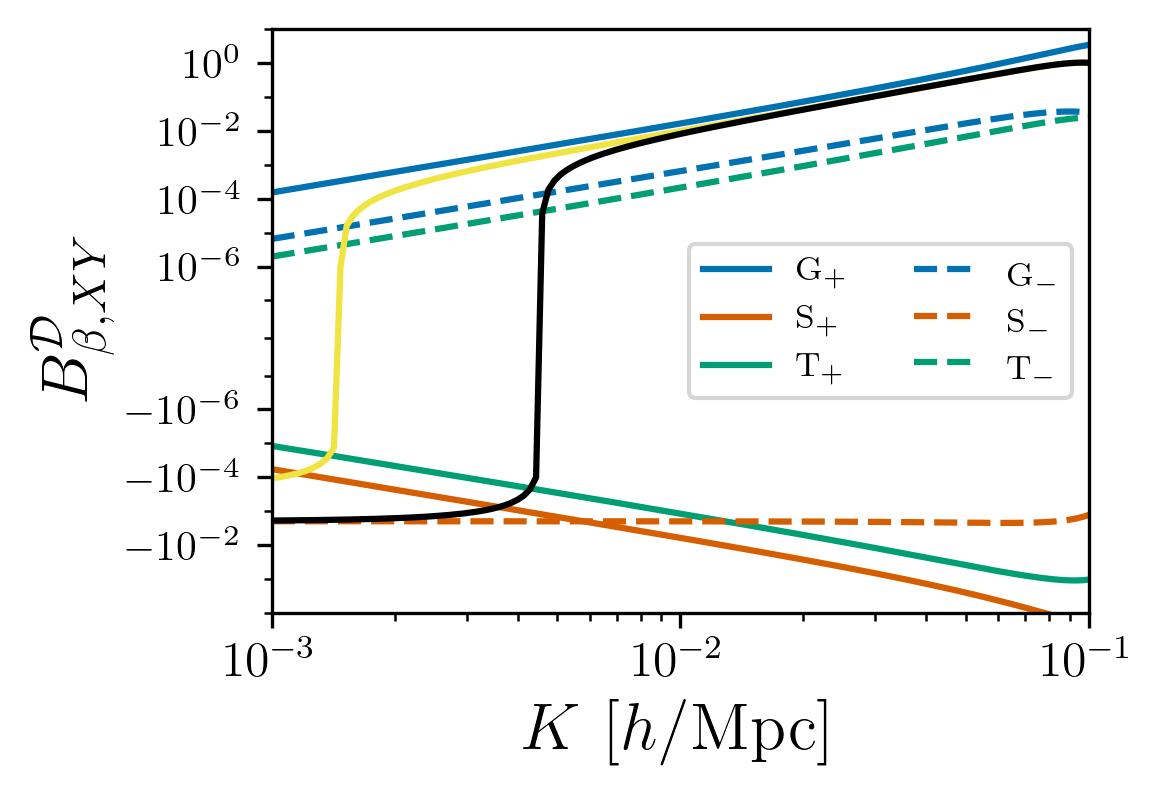

In [7]:
# ---- FIGURE CREATION ----
# Create figure with golden ratio and higher dpi
fig = plt.figure(figsize=(plot.size[0], plot.size[1]*1.2), dpi=plot.DPI, facecolor='white')
# Use GridSpec for more control over plot layout
gs = plot.GridSpec(1, 1, figure=fig, left=0.15, right=0.95, bottom=0.15, top=0.92)
ax = fig.add_subplot(gs[0, 0])

i = 0
color = plot.COLORBLIND_PALETTE[i % len(plot.COLORBLIND_PALETTE)]


# Set up clean, professional plot styling with pure white background
ax.set_facecolor('white')
for spine in ax.spines.values():
    spine.set_linewidth(0.8)
    spine.set_color('black')

keys = ["g", "s", "t", "ga", "sa", "ta"]

for i, k in enumerate(keys):
    color_ = plot.COLORBLIND_PALETTE[i%3]
    #print(estimator_biases[i])
    ax.loglog(Ks, estimator_biases[i], label = plot.names[k], color = color_, ls = "-" if i < 3 else "--", lw = 1.5)


#ax.loglog(Ks, estimator_biases_10[keys.index(kother)], label = plot.names[kother]+" ($\\epsilon \\times 0.1$)", color = plot.COLORBLIND_PALETTE[6], ls = "--")
ax.loglog(Ks, estimator_biases_10.sum(axis = 0), color = plot.COLORBLIND_PALETTE[6], ls = "-", lw = 1.5)

ax.loglog(Ks, estimator_biases.sum(axis = 0), color = "black", lw = 1.5)
    
ax.set_xlabel(r'$K \ [h/\mathrm{Mpc}]$', fontsize=16)

ax.set_ylabel(r'$B^{{\mathcal{D}}}_{\beta,XY}$', fontsize=16)

ax.legend(ncol = 2, loc = "best", fontsize = 8)
ax.set_xlim(1e-3, 1e-1)

from matplotlib.ticker import SymmetricalLogLocator
#ax.yaxis.set_major_locator(SymmetricalLogLocator(linthresh=1e-7, base=10))

ax.set_yscale('symlog', linthresh = 1e-7)  # Adjust threshold based on your data

ax.set_ylim(-1, 1e1)


yticks = [-1e-2, -1e-4, -1e-6, 1e-6, 1e-4, 1e-2, 1e0]
ax.set_yticks(yticks)


fig.savefig(f"/users/odarwish/long-modes/figures/bias.pdf", dpi = 300, bbox_inches='tight')
plt.show()
plt.close()

## Compare variance

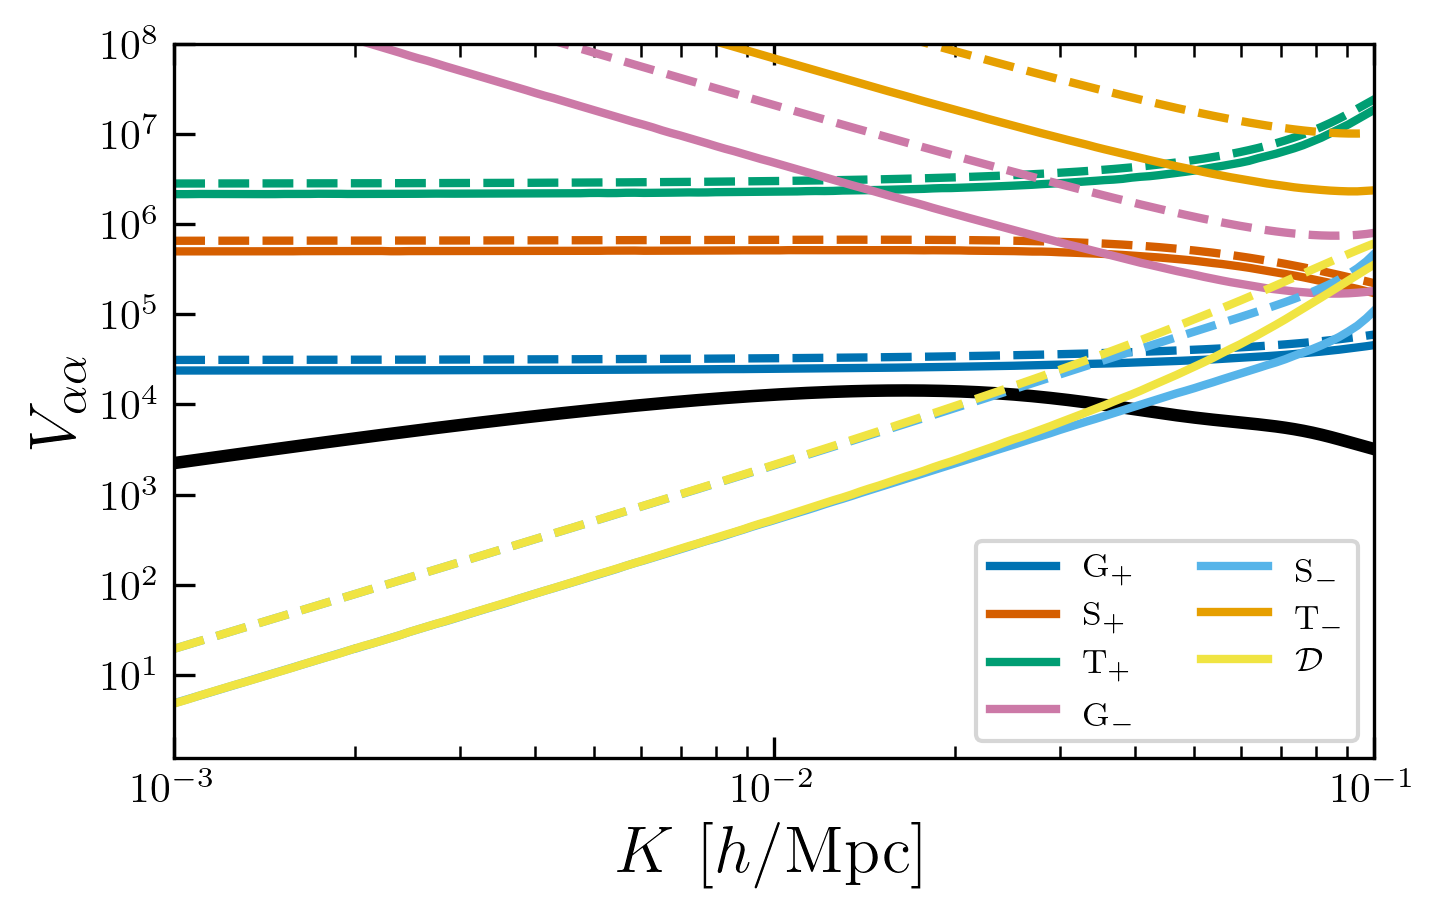

In [8]:
def get(mainkey):
    key = (mainkey, mainkey)
    N = norm[key]**-1.
    V = var[key]*N**2
    return N, V

# ---- FIGURE CREATION ----
# Create figure with golden ratio and higher dpi
fig = plt.figure(figsize=(plot.FIG_WIDTH, plot.FIG_HEIGHT), dpi=plot.DPI, facecolor='white')
# Use GridSpec for more control over plot layout
gs = plot.GridSpec(1, 1, figure=fig, left=0.15, right=0.95, bottom=0.15, top=0.92)
ax = fig.add_subplot(gs[0, 0])

# Professional tick parameters
ax.tick_params(axis='both', which='major', direction='in', length=5, width=0.8, 
               top=True, right=False, labelsize=10)
ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.6, 
               top=True, right=False)

i = 0
color = plot.COLORBLIND_PALETTE[i % len(plot.COLORBLIND_PALETTE)]

# Set up clean, professional plot styling with pure white background
ax.set_facecolor('white')
for spine in ax.spines.values():
    spine.set_linewidth(0.8)
    spine.set_color('black')

ax.plot(Ks, plinf(Ks), color = "black", lw = 3)

keys = ["g", "s", "t", "ga", "sa", "ta", "n"]#, "t", "ga", "sa", "ta", "n"]

for i, k in enumerate(keys):
    color_ = plot.COLORBLIND_PALETTE[i]
    N, V = get(k)
    ax.loglog(Ks, V, label = plot.names[k], color = color_, lw = 2)
    ax.loglog(Ks, N, color = color_, ls = "--", lw = 2)
    #print(V/N)

ax.set_xlabel(r'$K \ [h/\mathrm{Mpc}]$', fontsize=16)
ax.set_ylabel(r'$V_{{\alpha\alpha}}$', fontsize=16)

ax.legend(ncol = 2, loc = "lower right", fontsize = 8)
ax.set_xlim(1e-3, 1e-1)
ax.set_ylim(ymax = 1e8)

ax.set_yscale('symlog', linthresh = 1e-7)  # Adjust threshold based on your data
fig.savefig(f"/users/odarwish/long-modes/figures/variance.pdf", dpi = 300, bbox_inches='tight')
plt.show()
plt.close()

## Comparing with variance of optimal weights

In [120]:
from qeep import qeresults as qres

if True:
    configuration_full_weights_swapped = '../../configs/abacus/config_desi_asymm_full_var_swapped.yaml'
    
    configuration_full_weights = '../../configs/abacus/config_desi_asymm_full_var.yaml'
    configuration = '../../configs/abacus/config_desi_asymm.yaml'

    configuration_full_weights_low_shot = '../../configs/abacus/config_asymm_low_shot_optimal.yaml'
    configuration_low_shot = '../../configs/abacus/config_asymm_low_shot.yaml'

    configuration_full_weights_super_low_shot = '../../configs/abacus/config_asymm_super_low_shot_optimal.yaml'
    configuration_super_low_shot = '../../configs/abacus/config_asymm_super_low_shot.yaml'

else:
    configuration_full_weights = '../../configs/abacus/config_desi_full_var.yaml'
    configuration = '../../configs/abacus/config_desi.yaml'

with open(configuration_full_weights, 'r') as f:
    config_optimal = yaml.safe_load(f)
with open(configuration_full_weights_swapped, 'r') as f:
    config_optimal_swapped = yaml.safe_load(f)
with open(configuration, 'r') as f:
    config = yaml.safe_load(f)
    
with open(configuration_full_weights_low_shot, 'r') as f:
    config_optimal_low_shot = yaml.safe_load(f)
with open(configuration_low_shot, 'r') as f:
    config_low_shot = yaml.safe_load(f)

    
with open(configuration_full_weights_super_low_shot, 'r') as f:
    config_optimal_super_low_shot = yaml.safe_load(f)
with open(configuration_super_low_shot, 'r') as f:
    config_super_low_shot = yaml.safe_load(f)
    
QR = qres.QEResults(config_optimal, relative_path = "../")
get_norm_opt = QR.get_get_norm()
get_var_opt = QR.get_get_variance()

QR = qres.QEResults(config_optimal_swapped, relative_path = "../")
get_norm_opt_swapped = QR.get_get_norm()
get_var_opt_swapped = QR.get_get_variance()

QR = qres.QEResults(config, relative_path = "../")
get_norm = QR.get_get_norm()
get_var = QR.get_get_variance()

QR = qres.QEResults(config_low_shot, relative_path = "../")
get_norm_low = QR.get_get_norm()
get_var_low = QR.get_get_variance()

QR = qres.QEResults(config_optimal_low_shot, relative_path = "../")
get_norm_low_opt = QR.get_get_norm()
get_var_low_opt = QR.get_get_variance()

QR = qres.QEResults(config_super_low_shot, relative_path = "../")
get_norm_super_low = QR.get_get_norm()
get_var_super_low = QR.get_get_variance()

QR = qres.QEResults(config_optimal_super_low_shot, relative_path = "../")
get_norm_low_super_opt = QR.get_get_norm()
get_var_low_super_opt = QR.get_get_variance()

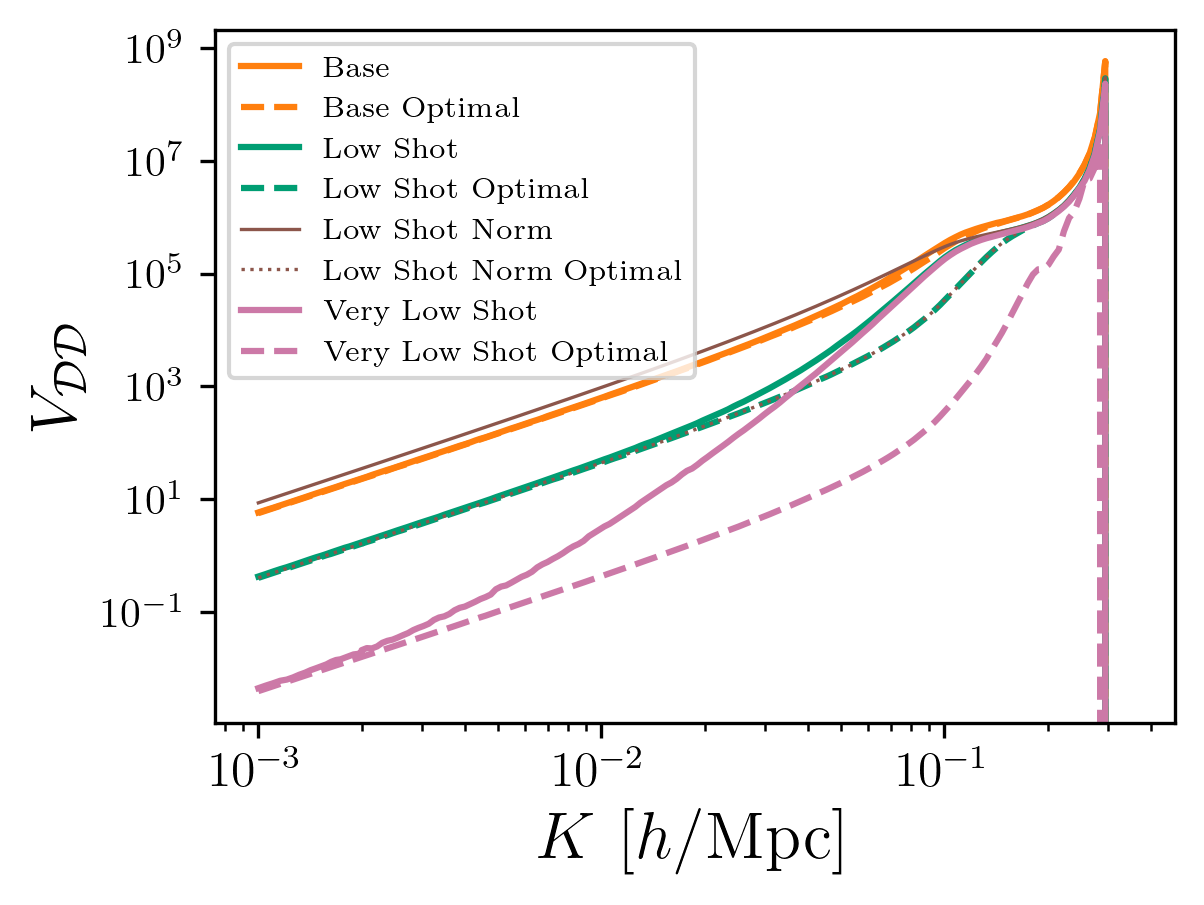

In [127]:
key = "n"

fig = plt.figure(figsize=(4, 3), dpi=plot.DPI, facecolor='white')
# Use GridSpec for more control over plot layout
gs = plot.GridSpec(1, 1, figure=fig, left=0.15, right=0.95, bottom=0.15, top=0.92)
ax = fig.add_subplot(gs[0, 0])

plot_norm = True
plot_var = True

N_base = 1#get_norm(key)#/4
V_base = 1#get_var(key)

if plot_var:
    #V_base = get_var(key)
    ax.loglog(Ks, get_var(key)/V_base, color = plot.COLORBLIND_PALETTE_2[1], label = "Base", lw = 1.5)
    ax.loglog(Ks, get_var_opt(key)/V_base, ls = "--", color = plot.COLORBLIND_PALETTE_2[1], label = "Base Optimal", lw = 1.5)

    #V_base = get_var_low(key)
    ax.loglog(Ks, get_var_low(key)/V_base, plot.COLORBLIND_PALETTE[2], label = "Low Shot", lw = 1.5)
    ax.loglog(Ks, get_var_low_opt(key)/V_base, ls = "--", color = plot.COLORBLIND_PALETTE[2], label = "Low Shot Optimal", lw = 1.5)
    #ax.loglog(Ks, get_var_opt_swapped(key)/V_base, color = "black", alpha = 0.4, label = "Var Optimal Swapped")


if plot_norm:
    
    ax.loglog(Ks, get_norm_low(key)/N_base, color = plot.COLORBLIND_PALETTE_2[5], label = "Low Shot Norm")
    ax.loglog(Ks, get_norm_low_opt(key)/N_base, ls = ":", color = plot.COLORBLIND_PALETTE_2[5], label = "Low Shot Norm Optimal")
    #ax.loglog(Ks, get_norm_opt_swapped(key)/N_base, color = "red", alpha = 0.4, label = "Norm Optimal Swapped")


if plot_var:
    #V_base = get_var_super_low(key)
    ax.loglog(Ks, get_var_super_low(key)/V_base, plot.COLORBLIND_PALETTE[3], label = "Very Low Shot", lw = 1.5)
    ax.loglog(Ks, get_var_low_super_opt(key)/V_base, ls = "--", color = plot.COLORBLIND_PALETTE[3], label = "Very Low Shot Optimal", lw = 1.5)


ax.legend(fontsize = 7, ncol = 1)
ax.set_xlabel(r'$K \ [h/\mathrm{Mpc}]$', fontsize=16)
ax.set_ylabel(r'$V_{{\mathcal{D}\mathcal{D}}}$', fontsize=16)

fig.savefig(f"/users/odarwish/long-modes/figures/variance_optimal.pdf", dpi = 300, bbox_inches='tight')
plt.show()
plt.close()

## Check shot bispectrum and trispectrum

In [11]:
mainkey = "n"

mainkey = "sa"
kother = "sa"

key = (mainkey, mainkey)
N = norm[key]**-1.


V = var[key]
T = tris[key]
S = bis[key]

plt.loglog(Ks, (V*N**2))
plt.loglog(Ks, (N), ls = "--")
plt.loglog(Ks, (S*N))

plt.loglog(Ks, abs(T*N**2), lw = 2)

plt.plot(Ks, plinf(Ks), lw = 2, color = "black", ls = "--")

KeyError: ('sa', 'sa')